# DFT clustering energy comparison

Compares clustered and dispersed solute configurations in a 54-atom BCC Fe supercell.

Only `numpy` and `matplotlib` are used.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Total energies

The energy difference is defined as

`Delta E = E_clustered - E_dispersed`.

A positive value means the dispersed configuration is lower in energy and therefore more stable.

In [2]:
ry_to_mev = 13605.7

energies_ry = {
    "fe54_pure": -13379.23285,
    "fe54_3ni_clustered": -13654.31167,
    "fe54_3ni_dispersed": -13654.32355,
    "fe54_5mo_clustered": -12837.86584,
    "fe54_5mo_dispersed": -12837.95000,
}

systems = ["Ni", "Mo"]
delta_e_ry = np.array([
    energies_ry["fe54_3ni_clustered"] - energies_ry["fe54_3ni_dispersed"],
    energies_ry["fe54_5mo_clustered"] - energies_ry["fe54_5mo_dispersed"],
])
delta_e_mev = delta_e_ry * ry_to_mev

for system, d_ry, d_mev in zip(systems, delta_e_ry, delta_e_mev):
    print(f"{system}: Delta E = {d_ry:.5f} Ry = {d_mev:.1f} meV")

Ni: Delta E = 0.01188 Ry = 161.6 meV
Mo: Delta E = 0.08416 Ry = 1145.1 meV


## Bar chart

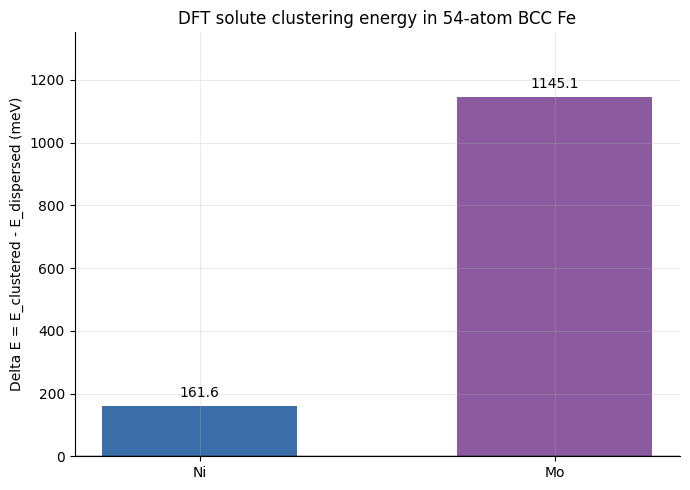

In [ ]:
x = np.arange(len(systems))

fig, ax = plt.subplots()
bars = ax.bar(x, delta_e_mev, width=0.55, color=["#3b6ea8", "#8c5b9f"])

ax.axhline(0, color="black", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(systems)
ax.set_ylabel("Delta E = E_clustered - E_dispersed (meV)")
ax.set_title("DFT solute clustering energy in 54-atom BCC Fe")

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{height:.1f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylim(0, delta_e_mev.max() * 1.18)
plt.tight_layout()
plt.show()

## Interpretation

Both systems have positive `Delta E`, so the dispersed solute configurations are lower in energy than the clustered configurations.

Therefore, clustering requires thermal activation at 480 degC, supporting Li et al.'s kinetic precipitation sequence.